<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
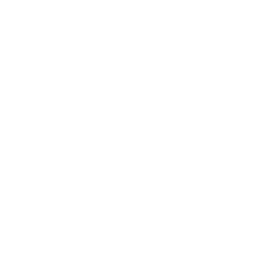
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Kemiallisen reaktorin häiriön diagnoosi</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Tunnista reaktorin T2-raja-arvon ylitystä selittävät muuttujat häiriötapahtuman aikana &nbsp;|&nbsp; Maaliskuu 2026</p>
</div>
</div>
</div>

## Tiivistelmä

Sekoitussäiliöreaktori (CSTR) ajautui lämpöhäiriöön, kun sen jäähdytysaineen syöttö heikkeni. Normaalikäytössä jäähdytysaineen virtaus, reaktorin lämpötila ja vaipan lämpötila liikkuvat yhdessä yhtä prosessikuormaa kuvaavaa akselia pitkin. Rakennamme kolmen komponentin MVP-mallin 100 normaalikäytön havainnosta ja pisteytämme sitten 100 häiriöhavaintoa sitä vasten `PROC MVPDIAGNOSE`-proseduurilla. Hotellingin *T*-neliö-tunnusluvun hajottaminen muuttujakohtaisiin kontribuutioihin paljastaa lämpökytkeytyneen kolmikon -- `jacket_temp`, `coolant_flow` ja `reactor_temp` -- ylityksen aiheuttajiksi, mikä ohjaa käyttöhenkilöstön suoraan jäähdytysjärjestelmän luo.


## Tietolähteet

| Aineisto | Rooli | Havainnot |
|---|---|---|
| `reactor_normal` | Normaalikäytön opetusaineisto MVP-mallille | 100 |
| `reactor_upset` | Häiriötapahtuman havainnot, jotka pisteytetään mallia vasten | 100 |

Kuusi mitattua muuttujaa ovat `reactor_temp` (C), `coolant_flow`
(l/min), `jacket_temp` (C), `feed_conc` (g/l) ja `pressure` (bar).
Molemmat aineistot on simuloitu jaetusta piilevästä *prosessikuormasta*, joten
normaaliaineisto kantaa saman korrelaatiorakenteen kuin oikea CSTR;
häiriö lisää jäähdytysaineen syötön menetyksen, joka rikkoo tuon rakenteen.


## Vaihe 1 -- Kouluta normaalikäytön MVP-malli

Normaalia käyttöä ohjaa piilevä prosessikuorma: suurempi kuorma laskee
jäähdytysaineen virtausta ja nostaa samalla reaktorin ja vaipan lämpötiloja.
`PROC MVPMODEL` poimii kolme pääkomponenttia 100 normaalihavainnosta ja
tallentaa ne `OUTMODEL=`-optiolla, jotta diagnoosivaihe voi pisteyttää uutta
dataa samaa vertailumallia vasten.


In [1]:
TIEDOT reactor_normal;
  CALL streaminit(7);
  TEE t = 1 ASTI 100;
    LOAD = rand('normal', 0, 1);                 /* piilevä prosessikuorma */
    reactor_temp = 85.0 + 2.5*LOAD + rand('normal', 0, 0.5);
    coolant_flow = 45.0 - 3.0*LOAD + rand('normal', 0, 0.6);
    jacket_temp  = 22.0 + 1.8*LOAD + rand('normal', 0, 0.4);
    feed_conc    =  2.4 + rand('normal', 0, 0.08);
    pressure     =  3.2 + 0.4*LOAD + rand('normal', 0, 0.05);
    TULOSTE;
  LOPPU;
SUORITA;

PROSEDUURI mvpmodel TIEDOT=reactor_normal outmodel=reactor_model;
  MUUTTUJA reactor_temp coolant_flow jacket_temp feed_conc pressure;
  NIMIKE reactor_temp='Reaktorin lämpötila' coolant_flow='Jäähdytysaineen virtaus'
        jacket_temp='Vaipan lämpötila' feed_conc='Syötön pitoisuus'
        pressure='Paine';
  ncomp=3;
SUORITA;



                    The MVPMODEL Procedure

  Data Set:          reactor_normal
  Number of Variables: 5
  Missing Value Handling: Exclude
  Number of Observations Read: 100
  Number of Observations Used: 100
  Number of Principal Components: 3

  Correlation Matrix
         Reaktorin lämpötilaJäähdytysaineen virtausVaipan lämpötilaSyötön pitoisuus     Paine
  Reaktorin lämpötila    1.0000   -0.9611    0.9530   -0.0726    0.9662
  Jäähdytysaineen virtaus   -0.9611    1.0000   -0.9636    0.0281   -0.9712
  Vaipan lämpötila    0.9530   -0.9636    1.0000    0.0008    0.9720
  Syötön pitoisuus   -0.0726    0.0281    0.0008    1.0000   -0.0326
  Paine     0.9662   -0.9712    0.9720   -0.0326    1.0000

  Eigenvalues of the Correlation Matrix
       Eigenvalue   Difference   Proportion  Cumulative
    1 3.89511286  2.89376076    0.7790    0.7790
    2 1.00135210  0.95664889    0.2003    0.9793
    3 0.04470321                0.0089    0.9882




NOTE: DATA reactor_normal


NOTE: Wrote reactor_normal (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MVPMODEL
NOTE: PROC MVPMODEL statement used.


## Vaihe 2 -- Pisteytä häiriötapahtuma ja hajota *T*-neliö

Häiriö vähentää jäähdytysaineen virtausta noin 12 l/min, kun taas reaktorin ja
vaipan lämpötilat nousevat -- normaali jäähdytysaineen/lämpötilan kytkentä on
rikkoutunut. `PROC MVPDIAGNOSE` pisteyttää jokaisen häiriöhavainnon
vertailumallia vasten, kirjoittaen standardoidut pisteet ja jäännökset
`OUT=`-aineistoon sekä muuttujakohtaiset *T*-neliö-kontribuutiot
`OUTCONTRIB=`-aineistoon. Jokainen havainto ylittää selvästi valvontarajan,
mikä vahvistaa jatkuvan moniulotteisen poikkeaman sen sijaan että kyse
olisi yksittäisestä kohinasta.


In [2]:
TIEDOT reactor_upset;
  CALL streaminit(101);
  TEE t = 1 ASTI 100;
    LOAD = rand('normal', 0, 1);
    /* Jäähdytyspumppu heikkenee: virtaus laskee, lämpötilat karkaavat */
    reactor_temp = 85.0 + 2.5*LOAD + rand('normal', 0, 0.5) + 8.0;
    coolant_flow = 45.0 - 3.0*LOAD + rand('normal', 0, 0.6) - 12.0;
    jacket_temp  = 22.0 + 1.8*LOAD + rand('normal', 0, 0.4) + 5.0;
    feed_conc    =  2.4 + rand('normal', 0, 0.08);
    pressure     =  3.2 + 0.4*LOAD + rand('normal', 0, 0.05);
    obs_time = t;
    TULOSTE;
  LOPPU;
SUORITA;

PROSEDUURI mvpdiagnose TIEDOT=reactor_upset MODEL=reactor_model
                 out=reactor_scores;
  MUUTTUJA reactor_temp coolant_flow jacket_temp feed_conc pressure;
  id obs_time;
  outcontrib=reactor_contrib;
SUORITA;



                    The MVPDIAGNOSE Procedure

  Variables:           5
  Observations:        100
  T-squared limit:     14.8750
  Out-of-control:      100

  Out-of-control observations:
    Obs 1: T2 = 2090.8063
    Obs 2: T2 = 999.7924
    Obs 3: T2 = 1527.3324
    Obs 4: T2 = 2991.6777
    Obs 5: T2 = 3777.1420
    Obs 6: T2 = 1902.6525
    Obs 7: T2 = 3769.1715
    Obs 8: T2 = 2615.9714
    Obs 9: T2 = 1143.3295
    Obs 10: T2 = 3332.9549
    Obs 11: T2 = 2752.9890
    Obs 12: T2 = 2494.0743
    Obs 13: T2 = 3270.5544
    Obs 14: T2 = 5566.4499
    Obs 15: T2 = 3268.5867
    Obs 16: T2 = 3393.2374
    Obs 17: T2 = 1646.0731
    Obs 18: T2 = 2328.4410
    Obs 19: T2 = 1748.7747
    Obs 20: T2 = 3117.7899
    ... and 80 more





NOTE: DATA reactor_upset


NOTE: Wrote reactor_upset (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MVPDIAGNOSE
NOTE: PROC MVPDIAGNOSE statement used.


## Vaihe 3 -- Järjestä keskimääräiset kontribuutiot

`OUTCONTRIB=` kirjoittaa yhden rivin jokaista pisteytettyä havaintoa
kohden, ja jokaiselle prosessimuuttujalle oman `<muuttuja>_CONTRIB`-sarakkeen.
Näiden sarakkeiden keskiarvo antaa kunkin muuttujan keskimääräisen
kontribuution häiriöön; transponointi muotoilee yhden rivin yhteenvedon
siistiksi muuttuja/arvo-taulukoksi, joka järjestää häiriön aiheuttajat.


In [3]:
PROSEDUURI KESKIARVOT TIEDOT=reactor_contrib mean NOPRINT;
  MUUTTUJA reactor_temp_contrib coolant_flow_contrib jacket_temp_contrib
      feed_conc_contrib pressure_contrib;
  TULOSTE out=contrib_means
    mean=mc_reactor_temp mc_coolant_flow mc_jacket_temp
         mc_feed_conc mc_pressure;
SUORITA;

PROSEDUURI TRANSPOSE TIEDOT=contrib_means out=contrib_long name=metric;
  MUUTTUJA mc_reactor_temp mc_coolant_flow mc_jacket_temp
      mc_feed_conc mc_pressure;
SUORITA;

/* Liitä luettavat muuttujanimet ja keskimääräinen kontribuutioarvo */
TIEDOT contrib_ranked;
  ASETA contrib_long;
  PITUUS variable $30;
  JOS      metric = 'mc_reactor_temp' NIIN variable = 'Reaktorin lämpötila';
  MUUTEN JOS metric = 'mc_coolant_flow' NIIN variable = 'Jäähdytysaineen virtaus';
  MUUTEN JOS metric = 'mc_jacket_temp'  NIIN variable = 'Vaipan lämpötila';
  MUUTEN JOS metric = 'mc_feed_conc'    NIIN variable = 'Syötön pitoisuus';
  MUUTEN JOS metric = 'mc_pressure'     NIIN variable = 'Paine';
  mean_contrib = col1;
  SÄILYTÄ variable mean_contrib;
SUORITA;

PROSEDUURI LAJITTELE TIEDOT=contrib_ranked;
  MUKAAN LASKEVA mean_contrib;
SUORITA;

PROSEDUURI TULOSTA TIEDOT=contrib_ranked noobs;
  MUUTTUJA variable mean_contrib;
  NIMIKE variable='Muuttuja' mean_contrib='Keskimääräinen kontribuutio';
SUORITA;



                 Muuttuja     Keskimääräinen kontribuutio
-------------------------  ------------------------------
Vaipan lämpötila                            4177.66720283
Jäähdytysaineen virtaus                     2882.19501987
Reaktorin lämpötila                         1602.04200377
Paine                                        280.73140863
Syötön pitoisuus                              61.43535437




NOTE: PROC MEANS
NOTE: Output dataset contrib_means has 1 observations and 7 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC TRANSPOSE data=contrib_means

NOTE: Created 5 rows.
NOTE: Output written to ./work/9acf7ffc-5b5d-42b5-9ba3-255c1d0bc9ea/contrib_long.avro.
NOTE: DATA contrib_ranked


NOTE: Read 5 rows from contrib_long.
NOTE: Wrote contrib_ranked (5 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=contrib_ranked

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 5 rows from contrib_ranked.
NOTE: Wrote contrib_ranked (5 rows, 2 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=contrib_ranked

NOTE: PROC PRINT completed: 5 observations printed, 2 variables


## Vaihe 4 -- Kontribuutiokuvio

Kontribuutiokuvio tekee diagnoosista välittömän: lämpökytkeytynyt kolmikko --
`jacket_temp`, `coolant_flow` ja `reactor_temp` -- ylittää selvästi
muuttujat `feed_conc` ja `pressure`, jotka tuskin näkyvät. Kolme
hallitsevaa palkkia ovat juuri ne muuttujat, jotka jäähdytyskierto sitoo
toisiinsa, joten vika on yksiselitteisesti lämpöperäinen, ei syöttö- tai
paineongelma.



NOTE: PROC SGPLOT data=contrib_ranked

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


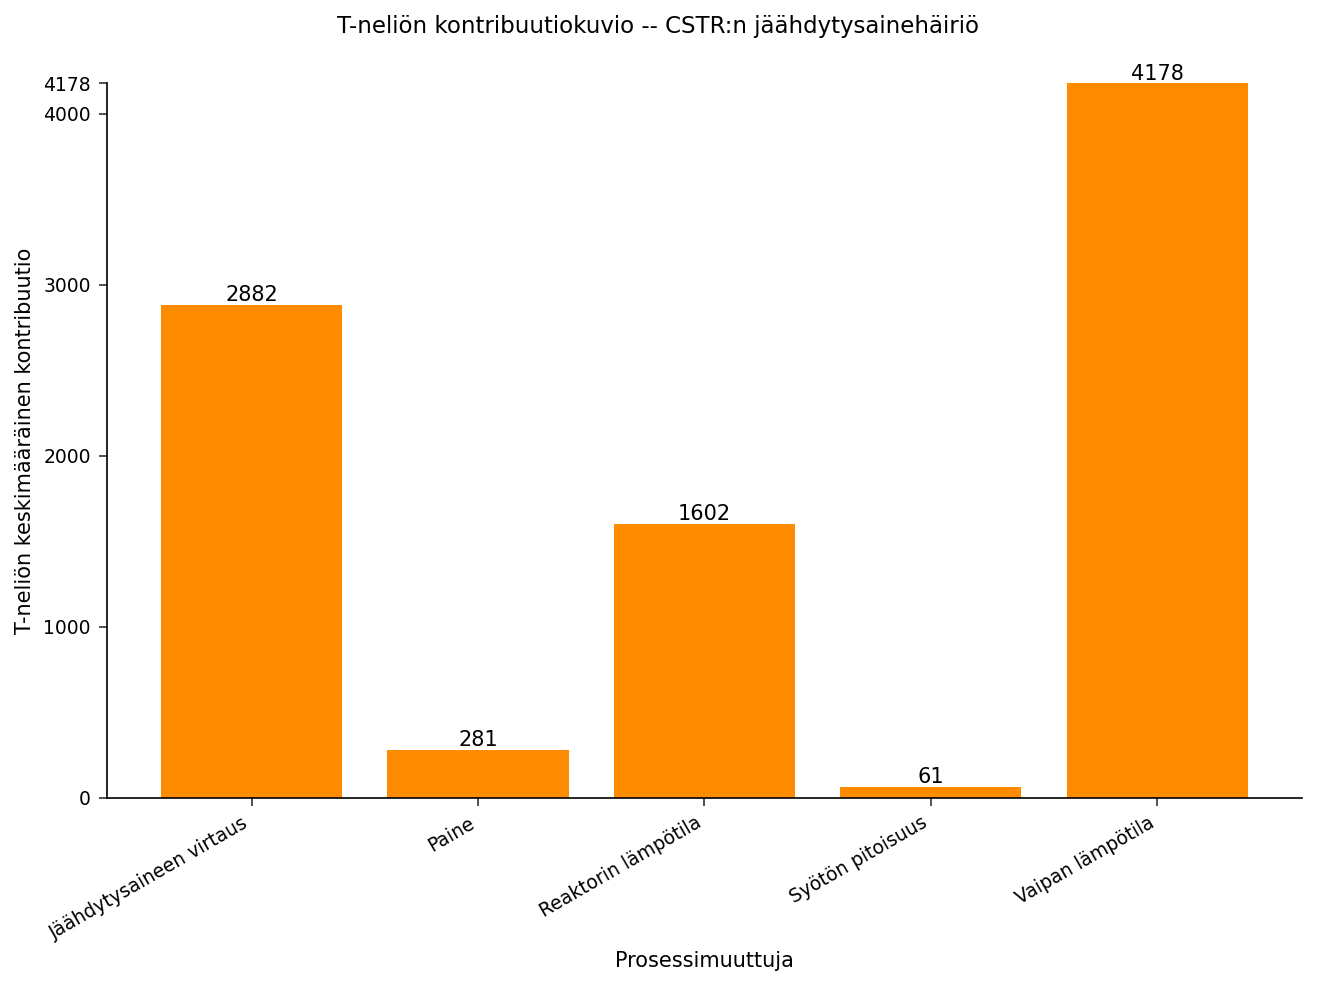

In [4]:
PROSEDUURI SGPLOT TIEDOT=contrib_ranked;
  VBAR variable / RESPONSE=mean_contrib
                  fillattrs=(color=darkorange)
                  DATALABEL;
  XAXIS NIMIKE='Prosessimuuttuja';
  YAXIS NIMIKE='T-neliön keskimääräinen kontribuutio';
  OTSIKKO 'T-neliön kontribuutiokuvio -- CSTR:n jäähdytysainehäiriö';
SUORITA;


## Vaihe 5 -- *T*-neliön valvonta-aikajana

Kunkin havainnon *T*-neliön piirtäminen mallin valvontarajaa vasten
osoittaa, että poikkeama on jatkuva: jokainen häiriöhavainto sijoittuu
suuruusluokkia rajaviivan yläpuolelle. Ikkunan sisällä ei tapahdu
palautumista, mikä sopii yhteen laitteistovian kanssa, joka jatkuu kunnes
jäähdytysjärjestelmä huolletaan.



NOTE: PROC SGPLOT data=reactor_scores

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


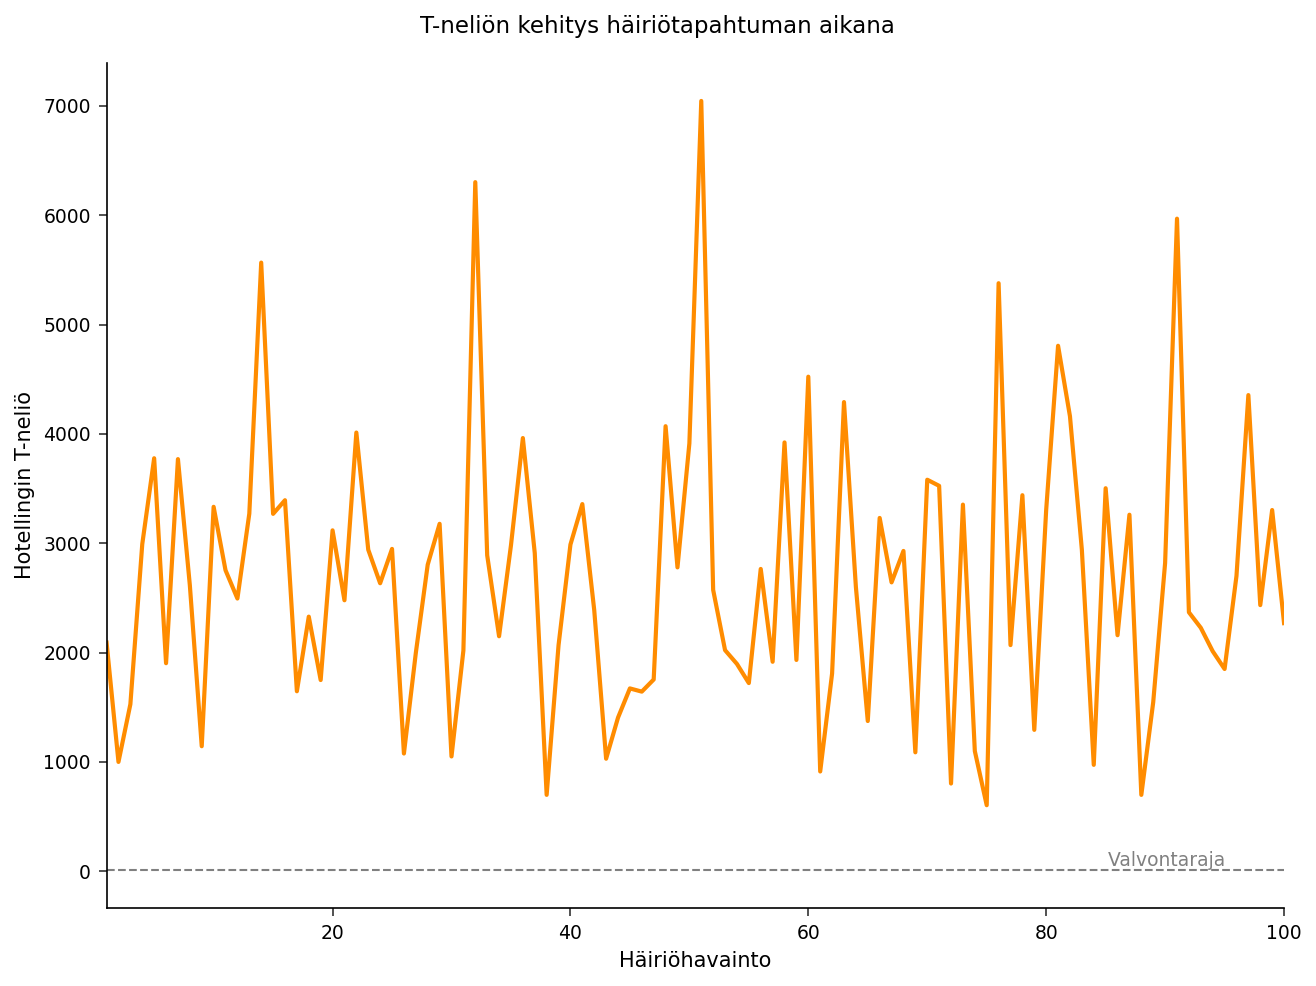

In [5]:
PROSEDUURI SGPLOT TIEDOT=reactor_scores;
  SERIES x=_OBS y=_TSQUARED / LINEATTRS=(color=darkorange thickness=2);
  REFLINE 14.87 / AXIS=y
                  NIMIKE='Valvontaraja'
                  LINEATTRS=(pattern=dash color=gray);
  XAXIS NIMIKE='Häiriöhavainto';
  YAXIS NIMIKE='Hotellingin T-neliö';
  OTSIKKO 'T-neliön kehitys häiriötapahtuman aikana';
SUORITA;


## Havainnot ja korjaavat toimet

- **Suurimmat aiheuttajat**: `jacket_temp`, `coolant_flow` ja `reactor_temp`
  vastaavat yhdessä käytännössä koko *T*-neliö-signaalista; niiden
  keskimääräiset kontribuutiot ovat kaksi--kolme suuruusluokkaa suurempia kuin
  `feed_conc`:n ja `pressure`:n.
- **Perimmäinen syy**: jäähdytysaineen syötön menetys. `coolant_flow` on
  ainoa *ohjattava* muuttuja näistä kolmesta -- lämpötilan nousut ovat
  jäähdytyksen menetyksen alavirran seurauksia, joten toiminnallinen
  vika on jäähdytysjärjestelmässä.
- **Valvontatila**: kaikki 100 häiriöhavaintoa ylittävät *T*-neliön
  rajan, mikä viittaa jatkuvaan poikkeamaan eikä hetkelliseen häiriöön.
- **Korjaava toimenpide**: tarkasta ja kunnosta jäähdytyspumppu; lisää
  redundantti jäähdytysaineen virtauslähetin, jotta tuleva syötön menetys
  havaitaan yksimuuttujaisella hälytyksellä ennen kuin se etenee
  lämpötilasilmukkaan.


## Vie järjestetyt kontribuutiot

Järjestetty kontribuutiotaulukko kirjoitetaan CSV-muotoon
häiriön jälkeistä raporttia ja jatkokäyttöpaneeleita varten.


In [6]:
PROSEDUURI VIE TIEDOT=contrib_ranked
            OUTFILE='reactor_upset_contributions.csv'
            DBMS=csv REPLACE;
SUORITA;



NOTE: PROC EXPORT data=contrib_ranked outfile=reactor_upset_contributions.csv

NOTE: Exported 5 rows to reactor_upset_contributions.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Luottamuksellinen
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Toteutettu käyttäen <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>